<a href="https://colab.research.google.com/github/josephfkung-del/DementiaBank-Classifcation/blob/main/Wafer_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
import sklearn
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/archive.zip"
extract_path = "/content/wafer_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)


Pipeline
Wafer Map --> preprocessing --> CNN --> defect predication

In [ ]:
df = pd.read_pickle("/content/wafer_data/LSWMD.pkl")
print(df.head())
print(df.info())
print(df.columns)

                                            waferMap  dieSize lotName  \
0  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
1  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
3  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
4  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   

   waferIndex trianTestLabel failureType  
0         1.0   [[Training]]    [[none]]  
1         2.0   [[Training]]    [[none]]  
2         3.0   [[Training]]    [[none]]  
3         4.0   [[Training]]    [[none]]  
4         5.0   [[Training]]    [[none]]  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotN

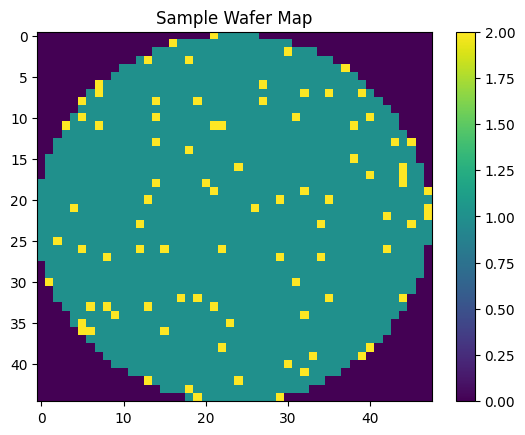

In [ ]:
#integer locating index(iloc)
sample = df.iloc[0]["waferMap"]
plt.imshow(sample)
plt.title("Sample Wafer Map")
plt.colorbar()
plt.show()

In [ ]:
import numpy as np

def clean_wafer_type(x):
    # Convert numpy array to list
    if isinstance(x, np.ndarray):
        x = x.tolist()

    # Handle empty labels like []
    if x == []:
        return None

    # Handle labels like [['none']] or [['Loc']]
    if isinstance(x, list):
        try:
            return x[0][0]
        except:
            return None

    # If it is already a string
    return x

df["label"] = df["failureType"].apply(clean_wafer_type)

df[["failureType", "label"]].head(50)




,failureType,label
0,[[none]],none
1,[[none]],none
2,[[none]],none
3,[[none]],none
4,[[none]],none
5,[[none]],none
6,[[none]],none
7,[[none]],none
8,[[none]],none
9,[[none]],none


In [ ]:
df["label"].value_counts()

,count
label,
none,147431
Edge-Ring,9680
Edge-Loc,5189
Center,4294
Loc,3593
Scratch,1193
Random,866
Donut,555
Near-full,149


In [ ]:
df_labeled = df.dropna(subset=["label"]).copy()

df_labeled["label"].value_counts()

,count
label,
none,147431
Edge-Ring,9680
Edge-Loc,5189
Center,4294
Loc,3593
Scratch,1193
Random,866
Donut,555
Near-full,149


In [ ]:
df_balanced = df_labeled.groupby("label", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 1000), random_state=42)
)

df_balanced["label"].value_counts()

/tmp/ipykernel_14625/2650651977.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df_labeled.groupby("label", group_keys=False).apply(


,count
label,
Center,1000
Edge-Loc,1000
Edge-Ring,1000
Loc,1000
none,1000
Scratch,1000
Random,866
Donut,555
Near-full,149


In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df_balanced["label"] = encoder.fit_transform(df_balanced["label"])
df_balanced["label"].value_counts()

for i, name in enumerate(encoder.classes_):
  print(i, name)

0 Center
1 Donut
2 Edge-Loc
3 Edge-Ring
4 Loc
5 Near-full
6 Random
7 Scratch
8 none


In [ ]:
df_balanced["label"].value_counts()

,count
label,
0,1000
2,1000
3,1000
4,1000
8,1000
7,1000
6,866
1,555
5,149


In [ ]:
import cv2
import numpy as np

IMG_SIZE = 64

def resize_wafer_map(wafer):
    wafer = np.array(wafer)
    wafer_resized = cv2.resize(
        wafer,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_NEAREST
    )
    return wafer_resized

X = np.array([
    resize_wafer_map(w) for w in df_balanced["waferMap"]
])

y = df_balanced["label"].values

print(X.shape)
print(y.shape)

(7570, 64, 64)
(7570,)


In [ ]:
X = X.astype("float32")

# Normalize values
X = X / X.max()

# Add channel dimension
X = np.expand_dims(X, axis=-1)

print(X.shape)

(7570, 64, 64, 1)


<Axes: xlabel='label'>

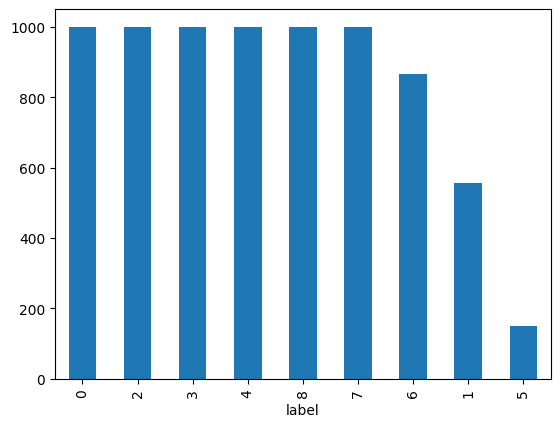

In [ ]:
df_balanced["label"].value_counts().plot(kind="bar")

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)

(6056, 64, 64, 1)
(1514, 64, 64, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

num_classes = len(df_balanced["label"].unique())

model = models.Sequential([
    layers.Input(shape=(64, 64, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,785 (2.61 MB)

 Trainable params: 683,785 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 36s 223ms/step - accuracy: 0.3522 - loss: 1.7000 - val_accuracy: 0.5883 - val_loss: 1.0854
Epoch 2/10
 62/152 ━━━━━━━━━━━━━━━━━━━━ 18s 207ms/step - accuracy: 0.5327 - loss: 1.1754

KeyboardInterrupt: 

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test accuracy:", test_acc)

In [ ]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(xticks_rotation=45)
plt.title("Wafer Defect Classification Confusion Matrix")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import random

indices = random.sample(range(len(X_test)), 9)

plt.figure(figsize=(10, 10))

for i, idx in enumerate(indices):
    image = X_test[idx].squeeze()
    true_label = encoder.classes_[y_test[idx]]
    pred_label = encoder.classes_[y_pred[idx]]

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Improvement

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))
print(class_weights)

In [ ]:
#near full i squite small
pairs_to_check = [
    ("Scratch", "Loc"),
    ("none", "Scratch"),
    ("none", "Loc"),
    ("Edge-Loc", "Loc"),
    ("Edge-Ring", "Edge-Loc")
]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

def show_mistakes(true_name, pred_name, max_images=10):
    true_id = list(encoder.classes_).index(true_name)
    pred_id = list(encoder.classes_).index(pred_name)

    idxs = np.where((y_test == true_id) & (y_pred == pred_id))[0]

    print(f"{true_name} predicted as {pred_name}: {len(idxs)} examples")

    for i in idxs[:max_images]:
        plt.imshow(X_test[i].squeeze(), cmap="gray")
        plt.title(f"True: {true_name}, Predicted: {pred_name}")
        plt.axis("off")
        plt.show()

show_mistakes("Scratch", "Loc")
show_mistakes("none", "Scratch")
show_mistakes("none", "Loc")
show_mistakes("Edge-Loc", "Loc")

DATA AUGMENTATION

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(np.unique(y_train, return_counts=True))

(6056, 64, 64, 1)
(6056,)
(array([0, 1, 2, 3, 4, 5, 6, 7, 8]), array([800, 444, 800, 800, 800, 119, 693, 800, 800]))


In [ ]:
import numpy as np

def augment_wafer(img):
    """
    Creates augmented versions of one wafer map.
    img shape should be (H, W, 1)
    """

    aug_images = []

    # Original
    aug_images.append(img)

    # Rotations
    aug_images.append(np.rot90(img, k=1, axes=(0, 1)))
    aug_images.append(np.rot90(img, k=2, axes=(0, 1)))
    aug_images.append(np.rot90(img, k=3, axes=(0, 1)))

    # Flips
    aug_images.append(np.flip(img, axis=0))  # vertical flip
    aug_images.append(np.flip(img, axis=1))  # horizontal flip

    # Small shifts
    aug_images.append(np.roll(img, shift=1, axis=0))
    aug_images.append(np.roll(img, shift=-1, axis=0))
    aug_images.append(np.roll(img, shift=1, axis=1))
    aug_images.append(np.roll(img, shift=-1, axis=1))

    return aug_images

In [ ]:
target_classes = [4, 7]  # 4 = Loc, 7 = Scratch

X_aug = []
y_aug = []

for img, label in zip(X_train, y_train):
    if label in target_classes:
        augmented_imgs = augment_wafer(img)

        for aug_img in augmented_imgs:
            X_aug.append(aug_img)
            y_aug.append(label)
    else:
        X_aug.append(img)
        y_aug.append(label)

X_train_aug = np.array(X_aug)
y_train_aug = np.array(y_aug)

print("Original training shape:", X_train.shape)
print("Augmented training shape:", X_train_aug.shape)
print(np.unique(y_train_aug, return_counts=True))

Original training shape: (6056, 64, 64, 1)
Augmented training shape: (20456, 64, 64, 1)
(array([0, 1, 2, 3, 4, 5, 6, 7, 8]), array([ 800,  444,  800,  800, 8000,  119,  693, 8000,  800]))


In [ ]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: split temporary data into validation and test
# This gives 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (5299, 64, 64, 1) (5299,)
Val: (1135, 64, 64, 1) (1135,)
Test: (1136, 64, 64, 1) (1136,)


In [ ]:
history = model.fit(
    X_train_aug,
    y_train_aug,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Wafer Defect Classification Confusion Matrix After Augmentation")
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test accuracy:", test_acc)

CNN Improvement

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten,
    Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam

num_classes = len(encoder.classes_)

model = Sequential([
    Conv2D(32, (3,3), padding="same", activation="relu", input_shape=X_train.shape[1:]),
    BatchNormalization(),
    Conv2D(32, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.20),

    Conv2D(64, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(64, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(128, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.30),

    Flatten(),

    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.45),

    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_aug,
    y_train_aug,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/80
640/640 ━━━━━━━━━━━━━━━━━━━━ 732s 1s/step - accuracy: 0.6495 - loss: 0.9902 - val_accuracy: 0.4035 - val_loss: 2.2826 - learning_rate: 0.0010
Epoch 2/80
640/640 ━━━━━━━━━━━━━━━━━━━━ 714s 1s/step - accuracy: 0.7984 - loss: 0.5284 - val_accuracy: 0.6819 - val_loss: 0.9765 - learning_rate: 0.0010
Epoch 3/80
640/640 ━━━━━━━━━━━━━━━━━━━━ 717s 1s/step - accuracy: 0.8668 - loss: 0.3628 - val_accuracy: 0.8502 - val_loss: 0.4270 - learning_rate: 0.0010
Epoch 4/80
640/640 ━━━━━━━━━━━━━━━━━━━━ 732s 1s/step - accuracy: 0.8932 - loss: 0.2947 - val_accuracy: 0.7938 - val_loss: 0.6255 - learning_rate: 0.0010
Epoch 5/80
640/640 ━━━━━━━━━━━━━━━━━━━━ 706s 1s/step - accuracy: 0.8993 - loss: 0.2794 - val_accuracy: 0.8203 - val_loss: 0.5749 - learning_rate: 0.0010
Epoch 6/80
640/640 ━━━━━━━━━━━━━━━━━━━━ 737s 1s/step - accuracy: 0.9087 - loss: 0.2483 - val_accuracy: 0.8899 - val_loss: 0.3187 - learning_rate: 0.0010
Epoch 7/80
640/640 ━━━━━━━━━━━━━━━━━━━━ 740s 1s/step - accuracy: 0.9199 - loss: 0.